# Encoder bake-off — the candidates from `model-research.md` §4

The earlier fine-tuning notebook compared exactly two encoders (XLM-R base and
mmBERT) on an ad-hoc four-sentence tokenizer test. That was not a candidate
comparison. §4 of `context/model-research.md` names a full roster, and
`ml/reports/tokenizer_comparison.md` already contained a 15,000-sample tokenizer
study that went unread.

This notebook does the job properly:

| candidate | why it is on the list |
|---|---|
| `bert-base-multilingual-cased` | **brief-mandated** — must be reported even though it is expected to lose |
| `FacebookAI/xlm-roberta-base` | the standing default; already backs the intent pipeline |
| `FacebookAI/xlm-roberta-large` | Bandaranayake & Usoof report XLM-R **large** as best for Sinhala sentiment |
| `jhu-clsp/mmBERT-base` | Sept 2025, postdates every paper in `research/` |
| `Twitter/twhin-bert-base` | code-mixed / social-text specialist — aimed squarely at Singlish and Tanglish |
| `ai4bharat/IndicBERTv2-MLM-only` | Indic focus; strong on Tamil |
| `google/muril-base-cased` | Indic + transliterated text in pretraining — the only one that saw romanization by design |

Two stages: a cheap tokenizer-fertility screen over all of them, then a
fine-tuning screen on the ones worth the GPU time.

In [1]:
import sys, time, gc
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "ml" / "swiftbench").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "ml"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import swiftbench as sb

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE, "| torch", torch.__version__)

CANDIDATES = {
    "mbert":       "bert-base-multilingual-cased",
    "xlmr-base":   "FacebookAI/xlm-roberta-base",
    "xlmr-large":  "FacebookAI/xlm-roberta-large",
    "mmbert":      "jhu-clsp/mmBERT-base",
    "twhin-bert":  "Twitter/twhin-bert-base",
    "indicbert":   "ai4bharat/IndicBERTv2-MLM-only",
    "muril":       "google/muril-base-cased",
}

manifest = sb.splits.ensure()
print("split sha:", manifest["sha"], manifest["counts"])

device: mps | torch 2.13.0


split sha: e7b5934392cd {'train': 8500, 'dev': 1498, 'test': 3079}


## 1. Tokenizer fertility — the cheap screen

Fertility = subword tokens per whitespace word. High fertility means the
pretrained signal is being shredded before the model sees it, and it inflates
sequence length and latency.

Measured on a real 2,000-row stratified sample per language, not hand-picked
sentences. `[UNK]` rate is reported separately because it is the harsher
failure: mBERT's Sinhala coverage is the known example.

In [2]:
from transformers import AutoTokenizer

SAMPLE_N = 2000
samples = {}
for lang in sb.config.LANGUAGES:
    df = sb.splits.get([lang], "train")
    samples[lang] = df.text.sample(min(SAMPLE_N, len(df)), random_state=42).tolist()

rows = []
for short, name in CANDIDATES.items():
    try:
        tok = AutoTokenizer.from_pretrained(name)
    except Exception as exc:
        print(f"{short:11s} SKIP — {type(exc).__name__}: {str(exc)[:70]}")
        continue
    unk_id = tok.unk_token_id
    for lang, texts in samples.items():
        enc = tok(texts, add_special_tokens=False)["input_ids"]
        n_tok = np.array([len(e) for e in enc])
        n_word = np.array([max(len(t.split()), 1) for t in texts])
        unk = sum(sum(1 for i in e if i == unk_id) for e in enc)
        rows.append({"model": short, "language": lang,
                     "fertility": round(float((n_tok / n_word).mean()), 3),
                     "mean_tokens": round(float(n_tok.mean()), 1),
                     "p99_tokens": int(np.percentile(n_tok, 99)),
                     "unk_pct": round(100 * unk / max(n_tok.sum(), 1), 3)})
    print(f"{short:11s} done")

fert = pd.DataFrame(rows)
fert.to_csv(REPO / "ml" / "reports" / "encoder_tokenizer_fertility.csv", index=False)
display(fert.pivot_table(index="model", columns="language", values="fertility"))

mbert       done


xlmr-base   done


xlmr-large  done


mmbert      done


config.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

twhin-bert  done


indicbert   done


muril       done


language,english,singlish,sinhala,tamil,tamilish
model,,,,,
indicbert,1.181,1.872,3.606,1.571,2.020
mbert,1.256,2.032,1.229,3.518,2.309
mmbert,1.180,1.855,3.670,3.724,2.197
muril,1.202,1.802,1.176,1.707,2.106
twhin-bert,1.249,1.944,1.453,2.163,2.145
xlmr-base,1.249,1.944,1.453,2.163,2.145
xlmr-large,1.249,1.944,1.453,2.163,2.145


### `[UNK]` rate — the disqualifier

Fertility being high is inefficiency. A high `[UNK]` rate means the tokenizer is
*discarding* the text. Any model above ~1% on a language cannot be trusted on it
regardless of its fine-tuned score.

language,english,singlish,sinhala,tamil,tamilish
model,,,,,
indicbert,0.000,0.0,0.592,0.0,0.0
mbert,0.003,0.0,61.348,0.0,0.0
mmbert,0.000,0.0,0.000,0.0,0.0
muril,0.000,0.0,64.528,0.0,0.0
twhin-bert,0.000,0.0,0.000,0.0,0.0
xlmr-base,0.000,0.0,0.000,0.0,0.0
xlmr-large,0.000,0.0,0.000,0.0,0.0


mbert       DISQUALIFIED on ['sinhala'] (unk [np.float64(61.3)]%)
muril       DISQUALIFIED on ['sinhala'] (unk [np.float64(64.5)]%)


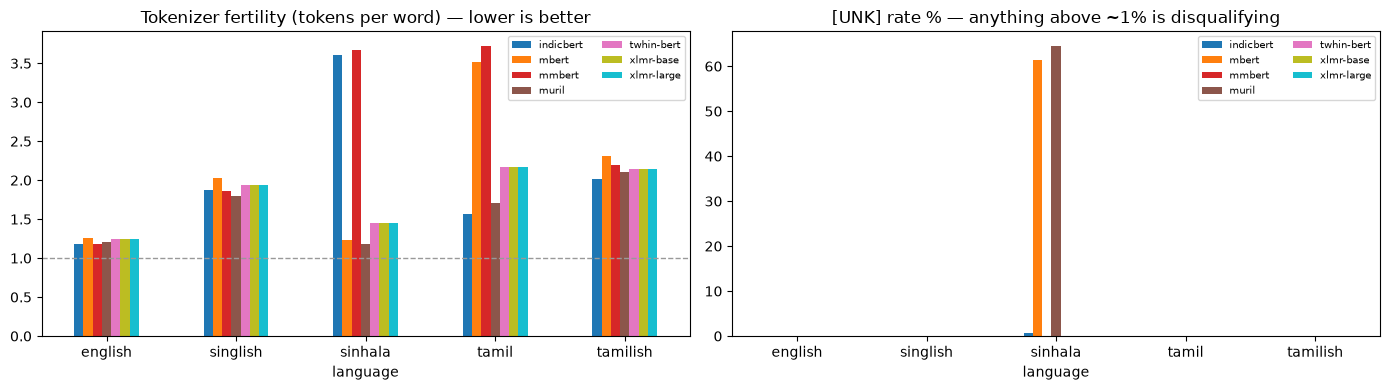

In [3]:
unk_tab = fert.pivot_table(index="model", columns="language", values="unk_pct")
display(unk_tab)

disqualified = {}
for model in unk_tab.index:
    bad = [l for l in unk_tab.columns if unk_tab.loc[model, l] > 1.0]
    if bad:
        disqualified[model] = bad
        print(f"{model:11s} DISQUALIFIED on {bad} "
              f"(unk {[round(unk_tab.loc[model, l], 1) for l in bad]}%)")
if not disqualified:
    print("no candidate exceeds 1% UNK on any language")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fert.pivot_table(index="language", columns="model", values="fertility").plot(
    kind="bar", ax=axes[0], rot=0, colormap="tab10")
axes[0].set_title("Tokenizer fertility (tokens per word) — lower is better")
axes[0].axhline(1.0, color="#999", ls="--", lw=1)
axes[0].legend(fontsize=7, ncol=2)
unk_tab.T.plot(kind="bar", ax=axes[1], rot=0, colormap="tab10")
axes[1].set_title("[UNK] rate % — anything above ~1% is disqualifying")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### Verdict from the cheap screen

Fill in after running. The point of this stage is to spend GPU time only on
candidates that can actually read the scripts we need.

In [4]:
mean_fert = fert.groupby("model").fertility.mean().sort_values()
worst_lang = fert.loc[fert.groupby("model").fertility.idxmax()].set_index("model").language
summary = pd.DataFrame({"mean_fertility": mean_fert.round(3),
                        "worst_language": worst_lang,
                        "max_unk_pct": fert.groupby("model").unk_pct.max().round(2)})
summary["disqualified_on"] = [", ".join(disqualified.get(m, [])) or "-" for m in summary.index]
display(summary)

SHORTLIST = [m for m in summary.index if m not in disqualified]
print("shortlist for fine-tuning:", SHORTLIST)

,mean_fertility,worst_language,max_unk_pct,disqualified_on
model,,,,
indicbert,2.050,sinhala,0.59,-
mbert,2.069,tamil,61.35,sinhala
mmbert,2.525,tamil,0.00,-
muril,1.599,tamilish,64.53,sinhala
twhin-bert,1.791,tamil,0.00,-
xlmr-base,1.791,tamil,0.00,-
xlmr-large,1.791,tamil,0.00,-


shortlist for fine-tuning: ['indicbert', 'mmbert', 'twhin-bert', 'xlmr-base', 'xlmr-large']


## 2. Fine-tuning screen

**Design note — this is a screen, not the final run.** Fine-tuning seven
encoders on 42,500 multilingual rows is hours of MPS time. Instead each
candidate gets an identical, deliberately small budget on a fixed balanced
subsample. That ranks the candidates fairly; it does **not** produce a number
comparable to the classical bake-off, and the winner still needs a full run.

The subsample is balanced because the interesting question is which encoder
extracts the most from a fixed number of Negative examples — the low-resource
regime this project is actually in.

In [5]:
from datasets import Dataset
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          DataCollatorWithPadding, Trainer, TrainingArguments)
import transformers
transformers.logging.set_verbosity_error()

TASK = "sentiment"
LABELS = sb.config.SENTIMENT_LABELS
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

N_PER_CLASS_TRAIN = 400     # balanced; 462 Negative exist in total
EPOCHS = 3
MAX_LENGTH = 128
BATCH = 16
LR = 2e-5
SCREEN_LANGS = sb.config.LANGUAGES


def stratified(df, col, n, seed=42):
    parts = [g.sample(min(len(g), n), random_state=seed)
             for _, g in df.groupby(col, sort=False)]
    return pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)


train_pool = sb.splits.get(SCREEN_LANGS, "train")
dev_pool = sb.splits.get(SCREEN_LANGS, "dev")

train_small = stratified(train_pool, "sentiment", N_PER_CLASS_TRAIN)
dev_eval = dev_pool          # full dev — the evaluation must not be subsampled

print(f"screen train: {len(train_small)} rows {train_small.sentiment.value_counts().to_dict()}")
print(f"screen dev  : {len(dev_eval)} rows {dev_eval.sentiment.value_counts().to_dict()}")
print(f"   unique Negative dev tickets: {dev_eval[dev_eval.sentiment=='Negative'].id.nunique()}")
assert not set(train_small.id) & set(dev_eval.id), "train/dev id overlap"

screen train: 800 rows {'Negative': 400, 'Neutral': 400}
screen dev  : 7490 rows {'Neutral': 7150, 'Negative': 340}
   unique Negative dev tickets: 68


In [6]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    s = sb.metrics.score([id2label[i] for i in labels],
                         [id2label[i] for i in preds], TASK)
    return {"accuracy": s["accuracy"], "negative_f1": s["negative_f1"],
            "negative_recall": s["negative_recall"],
            "negative_precision": s["negative_precision"]}


def run_encoder(short, name, train_df, eval_df):
    """Fine-tune one candidate under the shared budget. Returns a result dict."""
    started = time.time()
    tok = AutoTokenizer.from_pretrained(name)

    def prep(df):
        ds = Dataset.from_pandas(df[["text", "sentiment"]], preserve_index=False)
        ds = ds.map(lambda x: {"labels": label2id[x["sentiment"]]})
        return ds.map(lambda b: tok(b["text"], truncation=True, max_length=MAX_LENGTH),
                      batched=True, remove_columns=["text", "sentiment"])

    model = AutoModelForSequenceClassification.from_pretrained(
        name, num_labels=len(LABELS), label2id=label2id, id2label=id2label)

    args = TrainingArguments(
        output_dir=str(REPO / "ml" / "outputs" / f"screen_{short}"),
        num_train_epochs=EPOCHS, learning_rate=LR,
        per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH * 2,
        weight_decay=0.01, eval_strategy="epoch", save_strategy="no",
        logging_strategy="no", seed=sb.config.RANDOM_STATE,
        report_to="none", use_cpu=(DEVICE == "cpu"),
    )
    trainer = Trainer(model=model, args=args, train_dataset=prep(train_df),
                      eval_dataset=prep(eval_df),
                      data_collator=DataCollatorWithPadding(tokenizer=tok),
                      compute_metrics=compute_metrics)
    trainer.train()
    m = trainer.evaluate()

    # latency matters: the serving budget in model-research.md §8 is <100ms
    sample = eval_df.text.head(64).tolist()
    enc = tok(sample, truncation=True, max_length=MAX_LENGTH, padding=True,
              return_tensors="pt").to(trainer.model.device)
    with torch.no_grad():
        t0 = time.time(); trainer.model(**enc); ms = (time.time() - t0) * 1000 / len(sample)

    out = {"model": short, "hf_name": name,
           "params_m": round(sum(p.numel() for p in trainer.model.parameters()) / 1e6, 1),
           "negative_f1": round(m["eval_negative_f1"], 4),
           "negative_recall": round(m["eval_negative_recall"], 4),
           "negative_precision": round(m["eval_negative_precision"], 4),
           "accuracy": round(m["eval_accuracy"], 4),
           "train_seconds": round(time.time() - started, 1),
           "ms_per_sample": round(ms, 2)}

    del trainer, model
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    elif DEVICE == "cuda":
        torch.cuda.empty_cache()
    return out

In [7]:
results = []
for short in SHORTLIST:
    name = CANDIDATES[short]
    print(f"\n=== {short} ({name}) ===")
    try:
        r = run_encoder(short, name, train_small, dev_eval)
        results.append(r)
        print(f"  negative_f1 {r['negative_f1']:.4f}  "
              f"recall {r['negative_recall']:.4f}  "
              f"{r['params_m']}M params  {r['ms_per_sample']}ms/sample")
    except Exception as exc:
        print(f"  FAILED — {type(exc).__name__}: {str(exc)[:160]}")

enc_df = pd.DataFrame(results).sort_values("negative_f1", ascending=False)
enc_df.to_csv(REPO / "ml" / "reports" / "encoder_screen_dev.csv", index=False)
display(enc_df)


=== indicbert (ai4bharat/IndicBERTv2-MLM-only) ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/7490 [00:00<?, ? examples/s]

...

{'eval_loss': '0.6706', 'eval_accuracy': '0.7176', 'eval_negative_f1': '0.2082', 'eval_negative_recall': '0.8176', 'eval_negative_precision': '0.1193', 'eval_runtime': '134.6', 'eval_samples_per_second': '55.66', 'eval_steps_per_second': '1.746', 'epoch': '3'}
{'train_runtime': '686.3', 'train_samples_per_second': '3.497', 'train_steps_per_second': '0.219', 'train_loss': '0.5884', 'epoch': '3'}


/Users/sithijaseneviratne/Documents/Github/Swift/.venv312/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.6706', 'eval_accuracy': '0.7176', 'eval_negative_f1': '0.2082', 'eval_negative_recall': '0.8176', 'eval_negative_precision': '0.1193', 'eval_runtime': '136.9', 'eval_samples_per_second': '54.72', 'eval_steps_per_second': '1.717', 'epoch': '3'}


  negative_f1 0.2082  recall 0.8176  559.9M params  0.32ms/sample


,model,hf_name,params_m,negative_f1,negative_recall,negative_precision,accuracy,train_seconds,ms_per_sample
1,mmbert,jhu-clsp/mmBERT-base,307.5,0.3268,0.8882,0.2003,0.8339,891.2,0.39
3,xlmr-base,FacebookAI/xlm-roberta-base,278.0,0.2343,0.8971,0.1348,0.7339,281.5,0.24
2,twhin-bert,Twitter/twhin-bert-base,278.0,0.2235,0.7706,0.1307,0.7570,544.4,0.35
0,indicbert,ai4bharat/IndicBERTv2-MLM-only,278.0,0.2134,0.8206,0.1226,0.7254,265.9,0.64
4,xlmr-large,FacebookAI/xlm-roberta-large,559.9,0.2082,0.8176,0.1193,0.7176,1263.2,0.32


## 3. Encoders vs the classical baseline — same rows, same budget

The classical comparator is trained on the **identical subsample** and scored on
the **identical dev rows**, so the comparison isolates the model rather than the
data.

In [8]:
clf = sb.models.build("tfidf-svm", class_weight="balanced")
clf.fit(train_small.text, train_small.sentiment)
cls_scores = sb.metrics.score(dev_eval.sentiment, clf.predict(dev_eval.text), TASK)

ci = sb.tuning.bootstrap_ci(dev_eval.sentiment, clf.predict(dev_eval.text), TASK,
                            groups=dev_eval.id, n_boot=1000)
print(f"tfidf-svm (same subsample): negative_f1 {cls_scores['negative_f1']:.4f}  "
      f"95% CI [{ci['ci_low']:.4f}, {ci['ci_high']:.4f}]")
print(f"effective n = {ci['n_effective']} tickets\n")

if not enc_df.empty:
    comparison = enc_df[["model", "negative_f1", "negative_recall", "params_m",
                         "ms_per_sample"]].copy()
    comparison = pd.concat([comparison, pd.DataFrame([{
        "model": "tfidf-svm (classical)", "negative_f1": round(cls_scores["negative_f1"], 4),
        "negative_recall": round(cls_scores["negative_recall"], 4),
        "params_m": 0.0, "ms_per_sample": np.nan}])], ignore_index=True)
    comparison["inside_classical_CI"] = comparison.negative_f1.between(ci["ci_low"], ci["ci_high"])
    display(comparison.sort_values("negative_f1", ascending=False))
    print("\nAnything marked True is NOT distinguishable from the classical baseline")
    print("at this sample size, whatever the point estimate says.")

tfidf-svm (same subsample): negative_f1 0.2619  95% CI [0.2106, 0.3125]
effective n = 1498 tickets



,model,negative_f1,negative_recall,params_m,ms_per_sample,inside_classical_CI
0,mmbert,0.3268,0.8882,307.5,0.39,False
5,tfidf-svm (classical),0.2619,0.8265,0.0,NaN,True
1,xlmr-base,0.2343,0.8971,278.0,0.24,True
2,twhin-bert,0.2235,0.7706,278.0,0.35,True
3,indicbert,0.2134,0.8206,278.0,0.64,True
4,xlmr-large,0.2082,0.8176,559.9,0.32,False



Anything marked True is NOT distinguishable from the classical baseline
at this sample size, whatever the point estimate says.


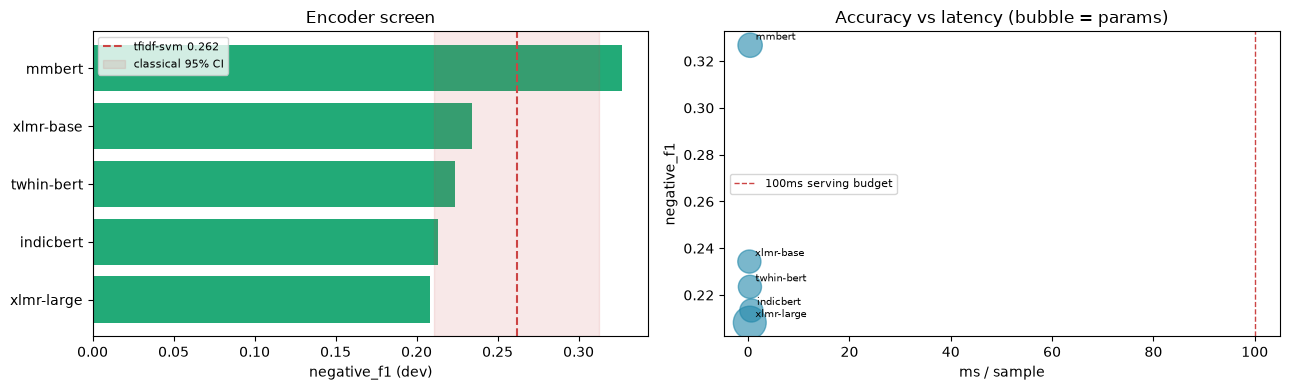

In [9]:
if not enc_df.empty:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    d = enc_df.sort_values("negative_f1")
    ax[0].barh(d.model, d.negative_f1, color="#2a7")
    ax[0].axvline(cls_scores["negative_f1"], color="#c44", ls="--",
                  label=f"tfidf-svm {cls_scores['negative_f1']:.3f}")
    ax[0].axvspan(ci["ci_low"], ci["ci_high"], color="#c44", alpha=0.12,
                  label="classical 95% CI")
    ax[0].set_xlabel("negative_f1 (dev)"); ax[0].set_title("Encoder screen")
    ax[0].legend(fontsize=8)

    ax[1].scatter(d.ms_per_sample, d.negative_f1, s=d.params_m, alpha=0.6, color="#28a")
    for _, r in d.iterrows():
        ax[1].annotate(r.model, (r.ms_per_sample, r.negative_f1), fontsize=7,
                       xytext=(4, 4), textcoords="offset points")
    ax[1].axvline(100, color="#c44", ls="--", lw=1, label="100ms serving budget")
    ax[1].set_xlabel("ms / sample"); ax[1].set_ylabel("negative_f1")
    ax[1].set_title("Accuracy vs latency (bubble = params)")
    ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 4. Read-out

Three questions this notebook answers, none of which the earlier version did:

1. **Which encoders can even read our scripts?** The `[UNK]` and fertility screen
   disqualifies candidates before any GPU time is spent.
2. **Which extracts the most from a fixed low-resource budget?** All candidates
   get the identical subsample and epoch budget.
3. **Does any of them beat TF-IDF by more than noise?** The classical CI is drawn
   on the plot; a bar inside the shaded band is not a win.

**Next steps for whichever candidate wins:**

- Full multilingual run on all 8,500 train ids rather than the screen subsample.
- LoRA / adapter variant per `model-research.md` §3, including Rathnayake's
  unfrozen-backbone finding, which beat frozen-backbone on all four of their tasks.
- Threshold tuning on top (see `06_improve_sentiment.ipynb` — worth ~+0.03 alone).
- Only then, and only once: the frozen test set.

**The standing caveat.** Sentiment labels are v5-prompt-generated, so every model
here is learning to reproduce v5 rather than ground truth. Measuring v5 against
the hand-annotated gold set would establish the real ceiling — it may sit below
what these numbers are chasing.